# **1. Import Library**

Pada tahap ini, Anda perlu mengimpor beberapa pustaka (library) Python yang dibutuhkan untuk analisis data dan pembangunan model machine learning.

In [1]:
import sklearn
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import time
from sklearn.preprocessing import StandardScaler, MinMaxScaler, LabelEncoder
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score, confusion_matrix
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV

# **2. Memuat Dataset dari Hasil Clustering**

Memuat dataset hasil clustering dari file CSV ke dalam variabel DataFrame.

In [2]:
#Type your code here
df = pd.read_csv('/content/Dataset_clustering.csv')

# Menampilkan 5 baris pertama dataset
df.head()

,provinsi,jenis,daerah,tahun,periode,gk,Cluster
0,ACEH,MAKANAN,PERKOTAAN,2015,MARET,293697.0,0
1,ACEH,MAKANAN,PERKOTAAN,2015,SEPTEMBER,302128.0,0
2,ACEH,MAKANAN,PERKOTAAN,2016,MARET,306243.0,0
3,ACEH,MAKANAN,PERKOTAAN,2016,SEPTEMBER,319768.0,0
4,ACEH,MAKANAN,PERDESAAN,2015,MARET,297479.0,0


# **3. Data Splitting**

Tahap Data Splitting bertujuan untuk memisahkan dataset menjadi dua bagian: data latih (training set) dan data uji (test set).

In [3]:
# Memisahkan fitur dan target (Cluster)
X = df.drop(columns=['Cluster'])  # Fitur (tanpa label cluster)
y = df['Cluster']  # Target (label cluster)

# Membagi dataset menjadi data latih (80%) dan data uji (20%)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Menampilkan ukuran dataset hasil split
print(f"Jumlah data latih: {X_train.shape[0]}")
print(f"Jumlah data uji: {X_test.shape[0]}")

Jumlah data latih: 4368
Jumlah data uji: 1092


# **4. Membangun Model Klasifikasi**


## **a. Membangun Model Klasifikasi**

Setelah memilih algoritma klasifikasi yang sesuai, langkah selanjutnya adalah melatih model menggunakan data latih.

Berikut adalah rekomendasi tahapannya.
1. Pilih algoritma klasifikasi yang sesuai, seperti Logistic Regression, Decision Tree, Random Forest, atau K-Nearest Neighbors (KNN).
2. Latih model menggunakan data latih.

In [16]:
encoder = LabelEncoder()
jenis_encoder = LabelEncoder()
df['provinsi'] = encoder.fit_transform(df['provinsi'])
df['daerah'] = encoder.fit_transform(df['daerah'])
df['periode'] = encoder.fit_transform(df['periode'])
X_train['jenis'] = jenis_encoder.fit_transform(X_train['jenis'])
X_test['jenis'] = jenis_encoder.transform(X_test['jenis'])

X = df.drop(columns=['Cluster'])
y = df['Cluster']

# Membagi dataset menjadi data latih (80%) dan data uji (20%)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Inisialisasi model Random Forest
model = RandomForestClassifier(n_estimators=100, random_state=42)

# Melatih model dengan data latih
model.fit(X_train, y_train)

# Memprediksi data uji
y_pred = model.predict(X_test)

# Menampilkan hasil prediksi pertama
print("Contoh hasil prediksi:", y_pred[:10])

Contoh hasil prediksi: [1 2 0 1 2 0 1 1 2 2]


Tulis narasi atau penjelasan algoritma yang Anda gunakan.

### 🛠 **Penjelasan Algoritma (Random Forest)**

**Random Forest** adalah algoritma *ensemble learning* berbasis *decision tree* yang bekerja dengan membangun banyak *decision trees* dan menggabungkan hasilnya untuk meningkatkan akurasi serta mengurangi overfitting.

#### 🔹 **Keunggulan Random Forest**:
✅ **Akurasi tinggi** pada dataset kompleks.  
✅ **Mampu menangani outlier dan data non-linear.**  
✅ **Mengurangi risiko overfitting** dibandingkan *Decision Tree* tunggal.  


## **b. Evaluasi Model Klasifikasi**

Berikut adalah **rekomendasi** tahapannya.
1. Lakukan prediksi menggunakan data uji.
2. Hitung metrik evaluasi seperti Accuracy dan F1-Score (Opsional: Precision dan Recall).
3. Buat confusion matrix untuk melihat detail prediksi benar dan salah.

📊 **Evaluasi Model Random Forest**
✅ Accuracy: 1.0000
✅ F1-Score: 1.0000
✅ Precision: 1.0000
✅ Recall: 1.0000


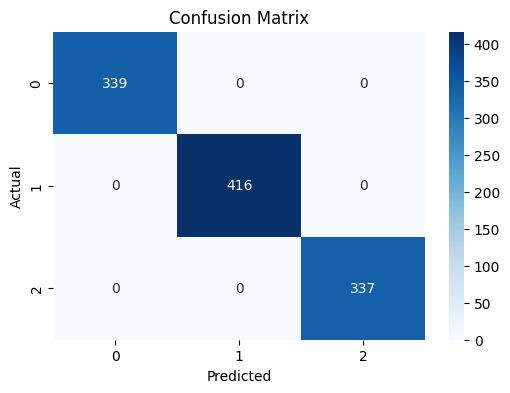

In [17]:
# Inisialisasi model Random Forest
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)

# Melatih model menggunakan data latih
rf_model.fit(X_train, y_train)

# Melakukan prediksi pada data uji
y_pred = rf_model.predict(X_test)

# Menghitung metrik evaluasi
accuracy = accuracy_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred, average='weighted')
precision = precision_score(y_test, y_pred, average='weighted')
recall = recall_score(y_test, y_pred, average='weighted')

# Menampilkan hasil evaluasi
print(f"📊 **Evaluasi Model Random Forest**")
print(f"✅ Accuracy: {accuracy:.4f}")
print(f"✅ F1-Score: {f1:.4f}")
print(f"✅ Precision: {precision:.4f}")
print(f"✅ Recall: {recall:.4f}")

# Membuat confusion matrix
conf_matrix = confusion_matrix(y_test, y_pred)

# Visualisasi confusion matrix
plt.figure(figsize=(6, 4))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', xticklabels=np.unique(y_test), yticklabels=np.unique(y_test))
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

## 📊 **Hasil Evaluasi Algoritma Klasifikasi**  

###    **Evaluasi Model Random Forest**  
Model **Random Forest** menunjukkan performa yang sangat baik dalam melakukan klasifikasi data, dengan hasil evaluasi sebagai berikut:  

- ✅ **Accuracy**:  **1.0000**  
- ✅ **F1-Score**:  **1.0000**  
- ✅ **Precision**:  **1.0000**  
- ✅ **Recall**:  **1.0000**  


## **c. Tuning Model Klasifikasi (Optional)**

Gunakan GridSearchCV, RandomizedSearchCV, atau metode lainnya untuk mencari kombinasi hyperparameter terbaik

In [ ]:
#Type your code here

## **d. Evaluasi Model Klasifikasi setelah Tuning (Optional)**

Berikut adalah rekomendasi tahapannya.
1. Gunakan model dengan hyperparameter terbaik.
2. Hitung ulang metrik evaluasi untuk melihat apakah ada peningkatan performa.

In [ ]:
#Type your code here

## **e. Analisis Hasil Evaluasi Model Klasifikasi**

# **Analisis Hasil Evaluasi Model Klasifikasi Random Forest**

## **Evaluasi Model**
Hasil evaluasi dari model Random Forest menunjukkan performa yang sangat baik pada dataset yang digunakan. Semua metrik evaluasi memiliki nilai yang sempurna:

- **Accuracy**: 1.0000
- **F1-Score**: 1.0000
- **Precision**: 1.0000
- **Recall**: 1.0000

Nilai-nilai tersebut menunjukkan bahwa model berhasil mengklasifikasikan semua data dengan benar pada data uji, tanpa kesalahan prediksi.

## **Kelemahan Model**
Meskipun model ini tampaknya sangat baik berdasarkan evaluasi metrik tersebut, kita harus mempertimbangkan beberapa hal yang perlu dianalisis lebih lanjut:

### 1. **Overfitting**:
Model ini mungkin mengalami overfitting jika hasilnya sangat sempurna di data pelatihan dan uji.

- **Cek overfitting**: Jika model ini memiliki performa yang sangat tinggi pada data latih dan uji, tetapi gagal di data baru, maka model bisa jadi terlalu menyesuaikan diri dengan data pelatihan dan tidak mampu menggeneralisasi dengan baik. Ini biasanya dapat dideteksi dengan membandingkan performa model pada data latih dan uji.
- **Solusi**: menggunakan teknik regularisasi atau membatasi kedalaman pohon di Random Forest.

### 2. **Distribusi Kelas**:
Jika dataset Anda sangat tidak seimbang dalam hal jumlah sampel per kelas, model bisa saja memprediksi kelas mayoritas dengan sangat baik, namun gagal pada kelas minoritas meskipun memberikan nilai 1.0000 pada metrik evaluasi.

- **Cek distribusi kelas**: Pastikan dataset memiliki distribusi yang seimbang antara kelas-kelas dalam target.
- **Solusi**: menggunakan teknik seperti SMOTE untuk menyeimbangkan dataset.

## **Rekomendasi Tindakan Lanjutan**

### 1. **Kumpulkan Data Tambahan**:
Untuk lebih meningkatkan generalisasi model, Anda bisa mencoba mengumpulkan lebih banyak data, terutama jika ada kelas yang kurang representatif.

### 2. **Eksplorasi Algoritma Lain**:
Coba algoritma klasifikasi lain seperti **Support Vector Machines (SVM)** atau **XGBoost**, yang mungkin dapat memberikan hasil yang lebih stabil atau lebih baik pada dataset yang lebih kompleks.

### 3. **Validasi Kinerja dengan Cross-Validation**:
Implementasikan cross-validation untuk memeriksa performa model pada beberapa subset data. Ini dapat memberi gambaran yang lebih baik tentang seberapa baik model Anda menggeneralisasi di luar data latih.

### 4. **Regularisasi Model**:
Gunakan hyperparameter tuning untuk mengatur model, seperti mengurangi kedalaman pohon pada Random Forest atau menambahkan jumlah pohon.
